In [272]:
!pip install tensorflow scikit-learn

In [273]:
import pandas as pd

In [274]:
import cv2
import numpy as np

def apply_clahe(img):
    """
    Applique le CLAHE sur l'image envoyée par le générateur Keras.
    L'image fournie par Keras est au format RGB.
    """
    # Keras transmet parfois les images en float32, on s'assure d'être en uint8 pour OpenCV
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
    
    # 1. Conversion de RGB vers l'espace colorimétrique LAB
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # 2. Application du CLAHE uniquement sur le canal de luminosité (L)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    
    # 3. Recombinaison des canaux et retour au format RGB
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe_rgb = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
    
    # Keras attend un format float pour la suite du pipeline
    return img_clahe_rgb.astype(np.float32)

In [275]:
raw_df = pd.read_csv('../data/raw_df.csv')
print(f"raw_df chargé : {len(raw_df)} lignes")
raw_df.head()

raw_df chargé : 84916 lignes


,path,width,height,ratio,blank,grayscale,mean_r,mean_g,mean_b,mean_intensity,is_duplicate_exact,is_duplicate_visual,is_duplicate
0,../images/image_train/image_1174594490_product...,500,500,1.0,False,False,152.110780,160.219872,165.382424,159.237692,False,False,False
1,../images/image_train/image_1172460449_product...,500,500,1.0,False,False,230.709380,230.757600,231.167372,230.878117,False,False,False
2,../images/image_train/image_1313553701_product...,500,500,1.0,False,False,219.699088,218.137696,218.556728,218.797837,False,False,False
3,../images/image_train/image_1008107210_product...,500,500,1.0,False,False,191.204772,190.752472,187.813376,189.923540,False,False,False
4,../images/image_train/image_1190251689_product...,500,500,1.0,False,False,187.136980,200.344364,220.304904,202.595416,False,False,False


In [276]:
# Filtrer les images vides/noires (blank == True)
df_clean = raw_df[raw_df['blank'] == False].copy()
print(f"df_clean après suppression des images vides/noires : {len(df_clean)} lignes")

df_clean après suppression des images vides/noires : 84866 lignes


In [277]:
# Extraction de l'ID image et de l'ID produit grâce à une expression régulière
# On cherche le motif "image_XXXX_product_YYYY"
df_clean[['imageid', 'productid']] = df_clean['path'].str.extract(r'image_(\d+)_product_(\d+)')

# On convertit ces nouvelles colonnes en entiers pour faciliter la jointure future
df_clean['imageid'] = df_clean['imageid'].astype(int)
df_clean['productid'] = df_clean['productid'].astype(int)

# Affichage pour vérifier l'extraction
display(df_clean[['path', 'imageid', 'productid']].head())

,path,imageid,productid
0,../images/image_train/image_1174594490_product...,1174594490,2940640728
1,../images/image_train/image_1172460449_product...,1172460449,185143847
2,../images/image_train/image_1313553701_product...,1313553701,4199252811
3,../images/image_train/image_1008107210_product...,1008107210,435919430
4,../images/image_train/image_1190251689_product...,1190251689,2738644573


In [278]:
# Jointure avec les métadonnées produit pour récupérer prdtypecode et designation
raw_x = pd.read_csv('../data/raw_x.csv')
raw_y = pd.read_csv('../data/raw_y.csv')

# Fusion raw_x + raw_y via l'identifiant Id pour obtenir prdtypecode
product_info = raw_x[['productid', 'imageid', 'Id']].merge(
    raw_y[['Id', 'prdtypecode']], on='Id', how='left'
).drop(columns=['Id'])

# Fusion avec df_clean sur le couple (imageid, productid)
df_clean = df_clean.merge(product_info, on=['imageid', 'productid'], how='left')

print(f"Après jointure des métadonnées : {len(df_clean)} lignes")
display(df_clean[['path', 'imageid', 'productid', 'prdtypecode']].head())

Après jointure des métadonnées : 84866 lignes


,path,imageid,productid,prdtypecode
0,../images/image_train/image_1174594490_product...,1174594490,2940640728,2583
1,../images/image_train/image_1172460449_product...,1172460449,185143847,1560
2,../images/image_train/image_1313553701_product...,1313553701,4199252811,40
3,../images/image_train/image_1008107210_product...,1008107210,435919430,2280
4,../images/image_train/image_1190251689_product...,1190251689,2738644573,2583


In [279]:
# Suppression des images dupliquées (risque de fuite train/val)
print(f"Avant : {len(df_clean)} lignes")
df_clean = df_clean[df_clean['is_duplicate'] == False].copy()
print(f"Après suppression des duplicatas : {len(df_clean)} lignes")

Avant : 84866 lignes
Après suppression des duplicatas : 77296 lignes


In [280]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [281]:
# 1. Conversion du code catégorie en type String (obligatoire pour la classification multiclasse dans Keras)
df_clean['prdtypecode'] = df_clean['prdtypecode'].astype(str)

# 2. Séparation stratifiée (80% train, 20% validation)
df_train, df_val = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['prdtypecode']
)

# 3. Configuration du générateur d'Entraînement (Normalisation + Data Augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

# 4. Configuration du générateur de Validation (Uniquement la normalisation, pas d'altération)
val_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255
    )

# Paramètres généraux
BATCH_SIZE = 32
TARGET_SIZE = (224, 224)

# 5. Création des flux (Générateurs)
print("--- Initialisation du flux d'entraînement ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='path',
    y_col='prdtypecode',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\n--- Initialisation du flux de validation ---")
val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='path',
    y_col='prdtypecode',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

--- Initialisation du flux d'entraînement ---
Found 61836 validated image filenames belonging to 27 classes.

--- Initialisation du flux de validation ---
Found 15460 validated image filenames belonging to 27 classes.


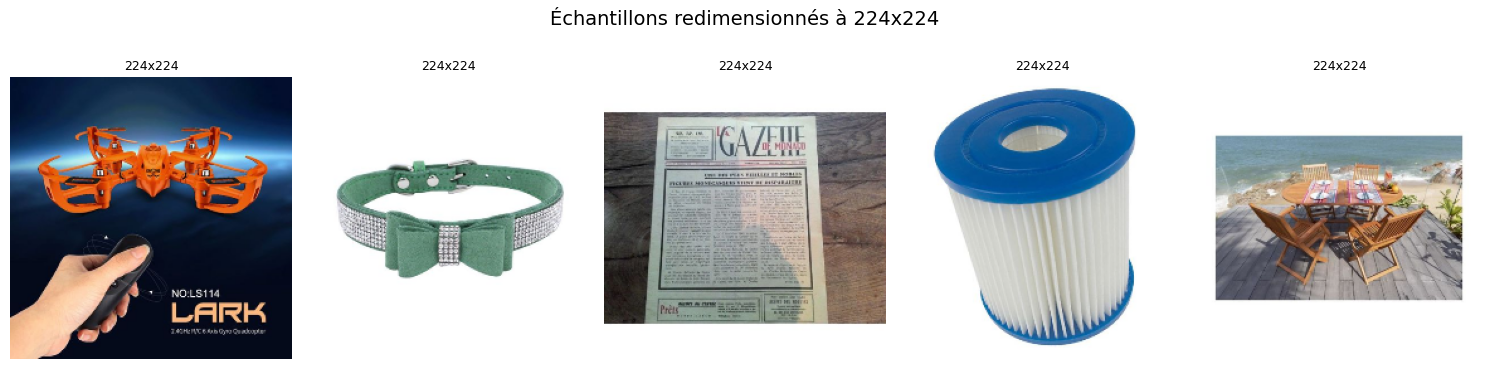

In [282]:
import matplotlib.pyplot as plt

# Visualisation d'échantillons redimensionnés à 224x224 (aléatoires)
sample_paths = df_clean['path'].sample(5).values

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, path in zip(axes, sample_paths):
    img = plt.imread(path)
    img_resized = cv2.resize(img, (224, 224))
    ax.imshow(img_resized)
    ax.set_title("224x224", fontsize=9)
    ax.axis('off')
plt.suptitle("Échantillons redimensionnés à 224x224", fontsize=14)
plt.tight_layout()
plt.show()

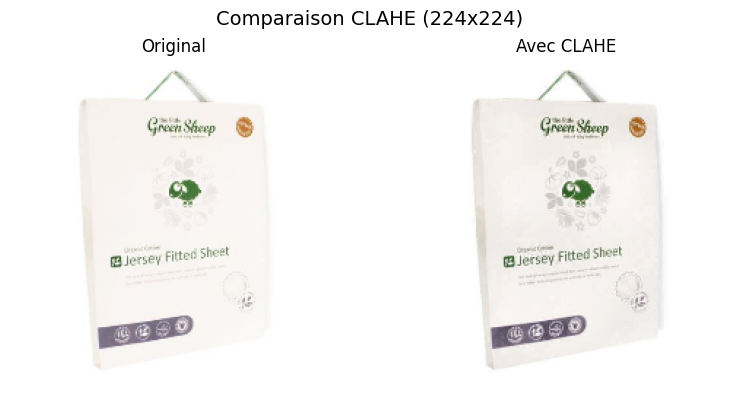

In [283]:
# Visualisation CLAHE avant / après (image aléatoire)
sample_path = df_clean['path'].sample(1).values[0]
img = plt.imread(sample_path)
img_resized = cv2.resize(img, (224, 224))

# Appliquer CLAHE via la fonction définie plus haut
img_clahe = apply_clahe(img_resized)
img_clahe_disp = np.clip(img_clahe / 255.0, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_resized)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(img_clahe_disp)
axes[1].set_title("Avec CLAHE")
axes[1].axis('off')
plt.suptitle("Comparaison CLAHE (224x224)", fontsize=14)
plt.tight_layout()
plt.show()

In [284]:
# Sauvegarder le jeu de données nettoyé
df_clean.to_csv('../data/df_clean.csv', index=False)
print(f"df_clean sauvegardé : {len(df_clean)} lignes")
df_clean.head()

df_clean sauvegardé : 77296 lignes


,path,width,height,ratio,blank,grayscale,mean_r,mean_g,mean_b,mean_intensity,is_duplicate_exact,is_duplicate_visual,is_duplicate,imageid,productid,prdtypecode
0,../images/image_train/image_1174594490_product...,500,500,1.0,False,False,152.110780,160.219872,165.382424,159.237692,False,False,False,1174594490,2940640728,2583
1,../images/image_train/image_1172460449_product...,500,500,1.0,False,False,230.709380,230.757600,231.167372,230.878117,False,False,False,1172460449,185143847,1560
2,../images/image_train/image_1313553701_product...,500,500,1.0,False,False,219.699088,218.137696,218.556728,218.797837,False,False,False,1313553701,4199252811,40
3,../images/image_train/image_1008107210_product...,500,500,1.0,False,False,191.204772,190.752472,187.813376,189.923540,False,False,False,1008107210,435919430,2280
4,../images/image_train/image_1190251689_product...,500,500,1.0,False,False,187.136980,200.344364,220.304904,202.595416,False,False,False,1190251689,2738644573,2583
